In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

all_native_df = add_ring_mean_columns(all_native_df)

all_native_labeled = all_native_df.copy()
all_native_labeled['dataset_label'] = 'Tutto il dataset nativo'

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('all_native_df:', all_native_df.shape)
print('all_native_labeled:', all_native_labeled.shape)

all_native_df: (3731, 73)
all_native_labeled: (3731, 74)


In [2]:
def build_rdf_long_df(df, metric_cols, radius_col='radius', n_rings=10, max_radius=50.0, bin_width=2.0, dataset_label='Tutto il dataset nativo'):
    records = []
    n_bins = int(max_radius / bin_width)

    for _, row in df.iterrows():
        radius = pd.to_numeric(row.get(radius_col), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for ring_id in range(1, n_rings + 1):
            metric_value = pd.to_numeric(row.get(metric_cols[ring_id - 1]), errors='coerce')
            if not np.isfinite(metric_value):
                continue

            ring_radius = float(radius) * (ring_id - 0.5) / n_rings
            if not np.isfinite(ring_radius) or ring_radius < 0 or ring_radius > max_radius:
                continue

            bin_id = min(int(ring_radius // bin_width) + 1, n_bins)
            records.append({
                'dataset_label': dataset_label,
                'ring_id': ring_id,
                'rdf_value': float(metric_value),
                'ring_radius_A': ring_radius,
                'radius_bin_id': bin_id,
                'radius_bin_center_A': bin_id * bin_width - bin_width / 2.0,
            })

    return pd.DataFrame.from_records(records)


palette = {'Tutto il dataset nativo': '#1f77b4'}

physical_plot_df = build_rdf_long_df(all_native_df, physical)
zernike_plot_df = build_rdf_long_df(all_native_df, zernike)
roughness_plot_df = build_rdf_long_df(all_native_df, roughness)

print('physical_plot_df:', physical_plot_df.shape)
print('zernike_plot_df:', zernike_plot_df.shape)
print('roughness_plot_df:', roughness_plot_df.shape)

physical_plot_df: (36937, 6)
zernike_plot_df: (36937, 6)
roughness_plot_df: (36937, 6)


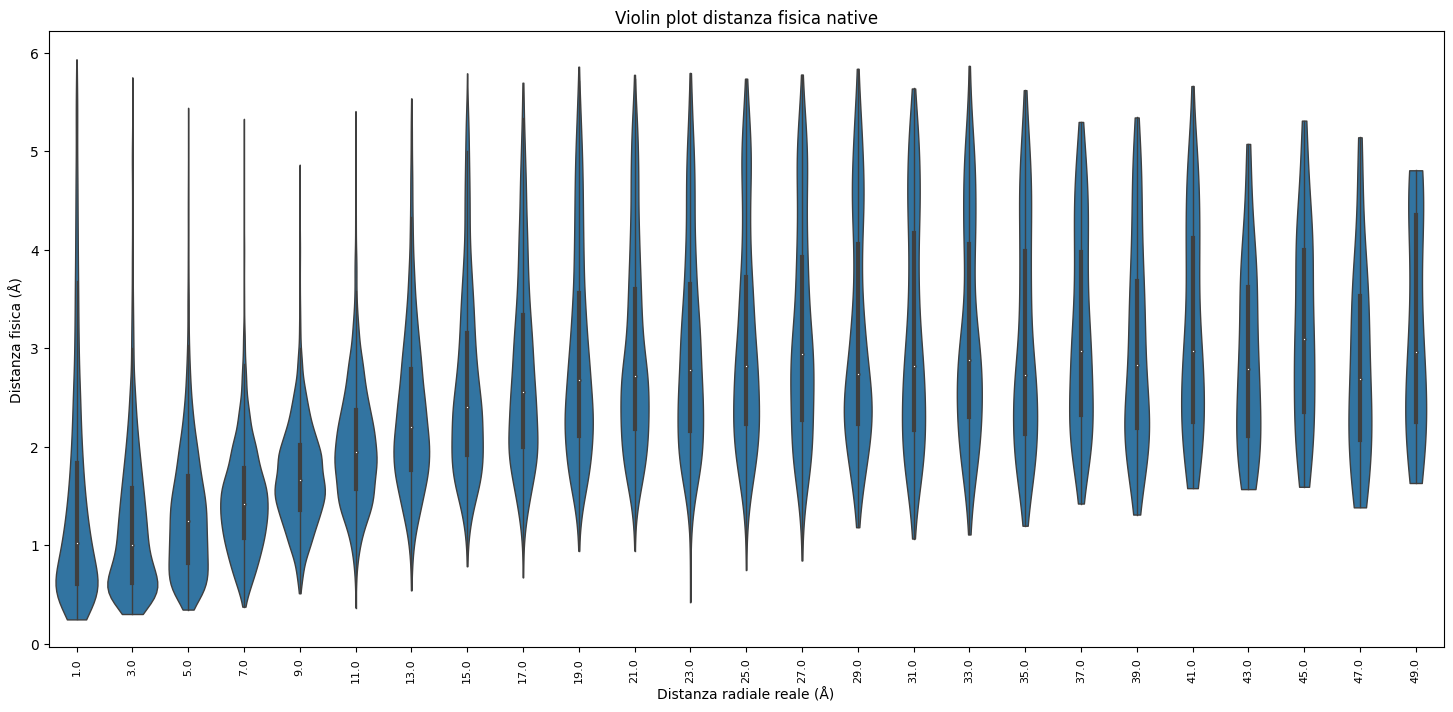

In [25]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=physical_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    color=palette['Tutto il dataset nativo'],
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
ax.set_title('Violin plot distanza fisica native')
ax.set_xlabel('Distanza radiale reale (Å)')
ax.set_ylabel('Distanza fisica (Å)')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
plt.savefig('plot_allnative/violinplot_physical.pdf', dpi=300, bbox_inches='tight')
plt.show()

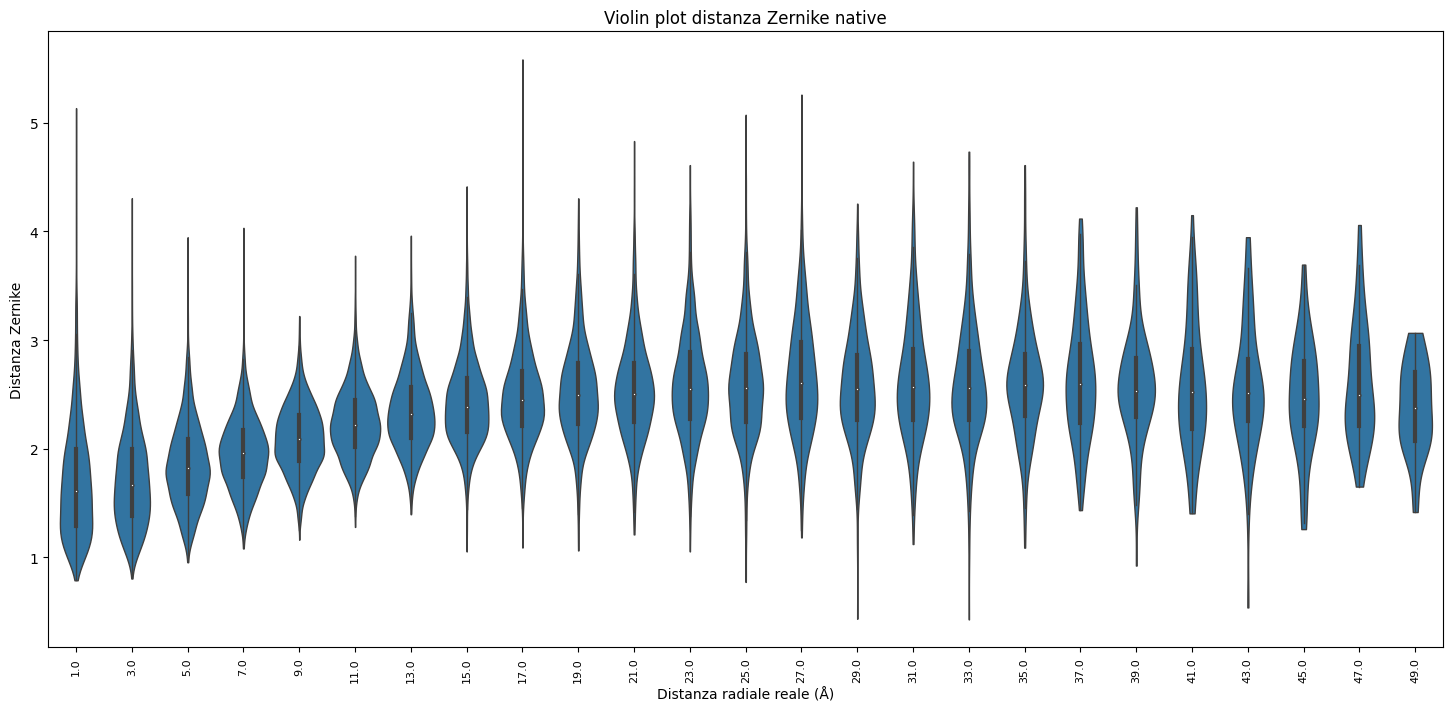

In [24]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=zernike_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    color=palette['Tutto il dataset nativo'],
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
ax.set_title('Violin plot distanza Zernike native')
ax.set_xlabel('Distanza radiale reale (Å)')
ax.set_ylabel('Distanza Zernike')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
plt.savefig('plot_allnative/violinplot_zernike.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
REAL_BIN_CENTERS = np.arange(25) * 2.0 + 1.0

In [14]:
def build_rdf_scatter_long_df(df, metric_cols, radius_col='radius', n_rings=10, max_radius=50.0, bin_width=2.0, dataset_label='Tutto il dataset nativo'):
    records = []
    n_bins = int(max_radius / bin_width)

    for _, row in df.iterrows():
        radius = pd.to_numeric(row.get(radius_col), errors='coerce')
        gyration_radius = pd.to_numeric(row.get('gyration_radius'), errors='coerce')
        binding_site_radius = pd.to_numeric(row.get('radius'), errors='coerce')
        roughness_global = pd.to_numeric(row.get('roughness'), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for ring_id in range(1, n_rings + 1):
            metric_value = pd.to_numeric(row.get(metric_cols[ring_id - 1]), errors='coerce')
            if not np.isfinite(metric_value):
                continue

            ring_radius = float(radius) * (ring_id - 0.5) / n_rings
            if not np.isfinite(ring_radius) or ring_radius < 0 or ring_radius > max_radius:
                continue

            bin_id = min(int(ring_radius // bin_width) + 1, n_bins)
            records.append({
                'complex_name': row.get('complex_name'),
                'dataset_label': dataset_label,
                'ring_id': ring_id,
                'rdf_value': float(metric_value),
                'ring_radius_A': ring_radius,
                'radius_bin_id': bin_id,
                'radius_bin_center_A': bin_id * bin_width - bin_width / 2.0,
                'gyration_radius': float(gyration_radius) if np.isfinite(gyration_radius) else np.nan,
                'binding_site_radius': float(binding_site_radius) if np.isfinite(binding_site_radius) else np.nan,
                'roughness_global': float(roughness_global) if np.isfinite(roughness_global) else np.nan,
            })

    return pd.DataFrame.from_records(records)


def build_dataset_matrix_with_globals(df, value_cols):
    return (
        df.groupby(['complex_name', 'dataset_label'], as_index=False)[value_cols + ['gyration_radius', 'radius', 'roughness']]
        .mean()
        .copy()
    )


physical_scatter_df = build_rdf_scatter_long_df(all_native_labeled, physical)


def _scatter_panel(ax, subset, global_col, global_label, title, color, label):
    if subset.empty:
        ax.set_axis_off()
        ax.set_title(f'{title} (nessun dato)')
        return

    ax.scatter(
        subset[global_col],
        subset['rdf_value'],
        s=10,
        alpha=0.45,
        color=color,
        edgecolors='none',
    )
    ax.set_title(title)
    ax.set_xlabel(global_label)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2, linestyle='--')


def _plot_scatter_grid(scatter_df, x_col, x_order, global_col, global_label, figure_title, label, ncols=5):
    n_items = len(x_order)
    nrows = int(np.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.5 * nrows), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for index, x_value in enumerate(x_order):
        row_index = index // ncols
        col_index = index % ncols
        ax = axes[row_index, col_index]
        subset = scatter_df[scatter_df[x_col] == x_value]
        _scatter_panel(ax, subset, global_col, global_label, f'Bin {x_value:.0f}±1 Å', palette['Tutto il dataset nativo'], label)

    for empty_index in range(n_items, nrows * ncols):
        row_index = empty_index // ncols
        col_index = empty_index % ncols
        axes[row_index, col_index].set_axis_off()

    fig.suptitle(figure_title, fontsize=15, fontweight='bold')
    return fig


def _plot_native_pc2_scatter(metric_cols, metric_label):
    metric_df = build_dataset_matrix_with_globals(all_native_labeled, metric_cols)
    scores, _ = _safe_pca_2d(metric_df[metric_cols])
    metric_df = metric_df.copy()
    metric_df['pc2'] = scores[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
    scatter_specs = [
        ('gyration_radius', 'Raggio di girazione (Å)'),
        ('radius', 'Raggio del sito di legame (Å)'),
        ('roughness', 'Rugosità (Å)'),
    ]

    for ax, (x_col, x_label) in zip(axes, scatter_specs):
        ax.scatter(metric_df[x_col], metric_df['pc2'], s=12, alpha=0.55, color=palette['Tutto il dataset nativo'], edgecolors='none')
        ax.set_title(f'{metric_label} - PC2 rispetto a {x_label}')
        ax.set_xlabel(x_label)
        ax.set_ylabel('PC2')
        ax.grid(alpha=0.2, linestyle='--')

    fig.suptitle(f'Grafico scatter PCA dei complessi nativi - {metric_label}', fontsize=15, fontweight='bold')
    plt.show()

In [7]:
zernike_scatter_df = build_rdf_scatter_long_df(all_native_labeled, zernike)

roughness_scatter_df = build_rdf_scatter_long_df(all_native_labeled, roughness)

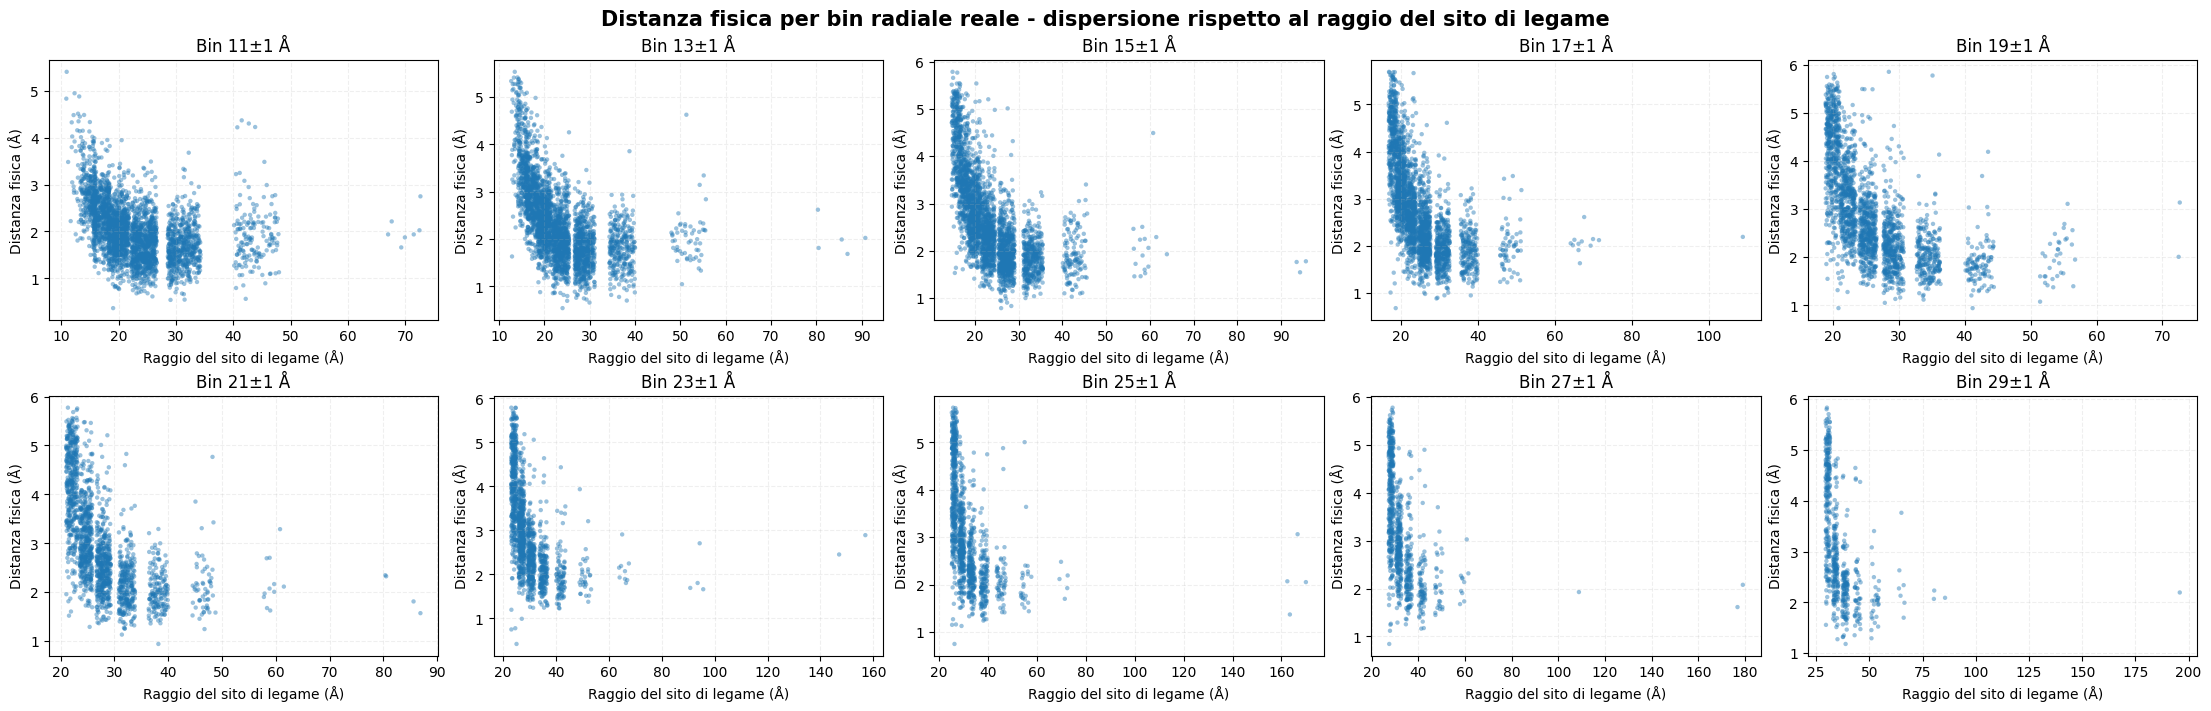

In [26]:
fig = _plot_scatter_grid(
    physical_scatter_df,
    x_col='radius_bin_center_A',
    x_order=[x for x in REAL_BIN_CENTERS if 11 <= x <= 29],
    global_col='binding_site_radius',
    global_label='Raggio del sito di legame (Å)',
    figure_title='Distanza fisica per bin radiale reale - dispersione rispetto al raggio del sito di legame',
    label = 'Distanza fisica (Å)',
    ncols=5,
)
plt.savefig('plot_allnative/scatter_physical.pdf', dpi=300, bbox_inches='tight')
plt.show()

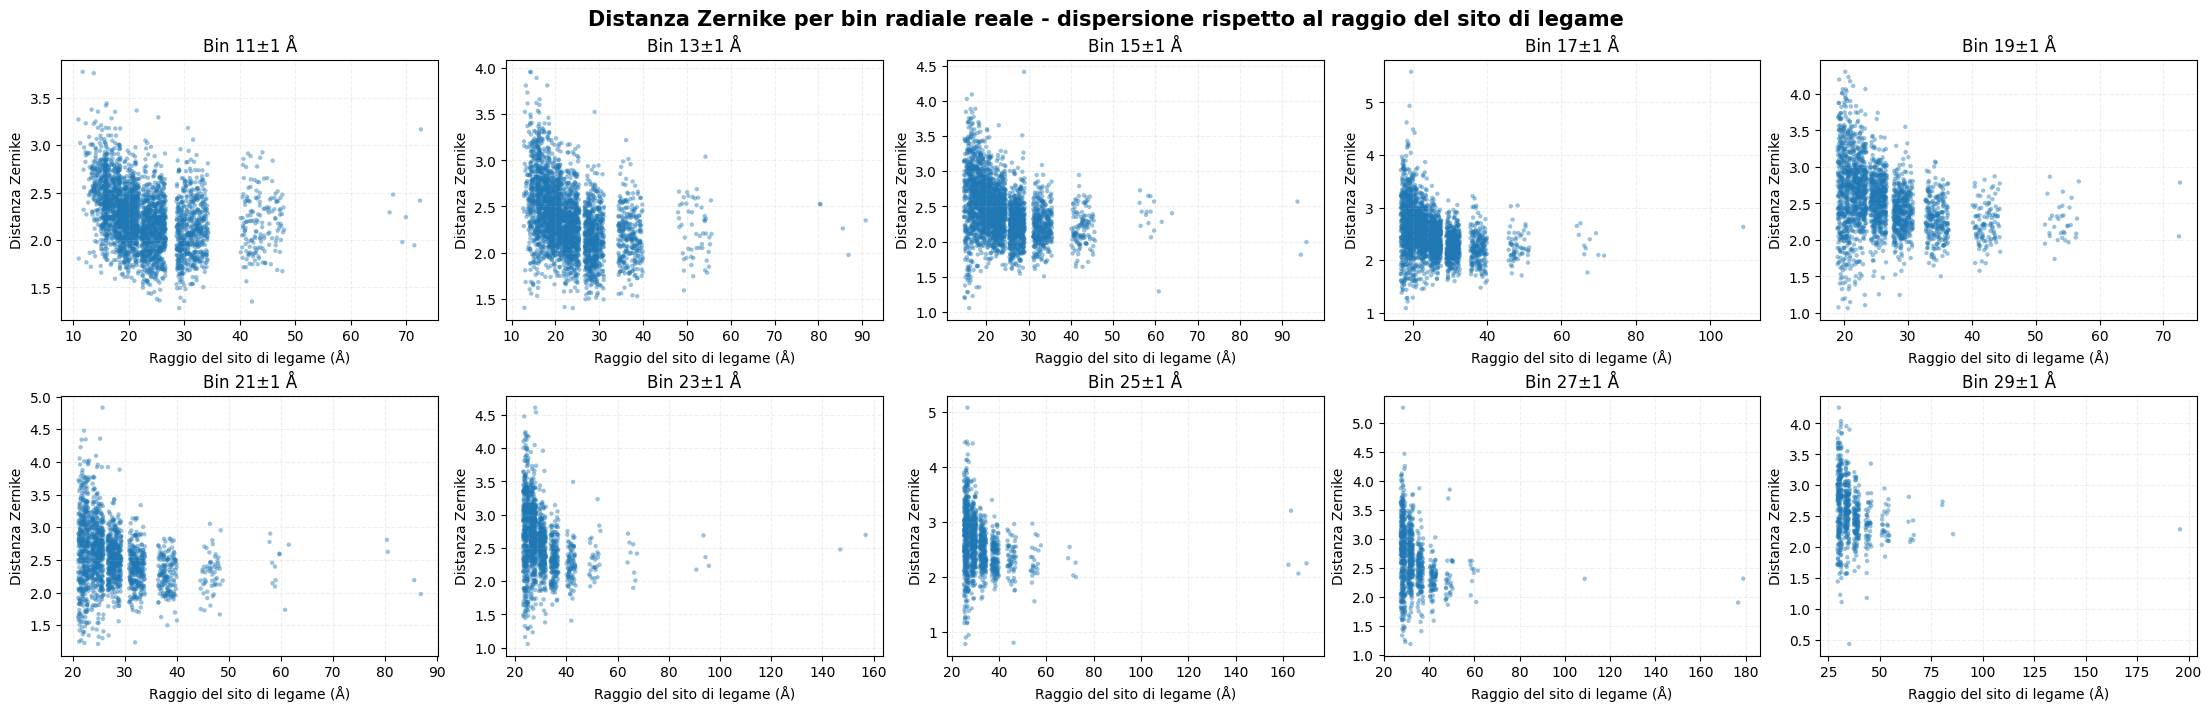

In [27]:
fig = _plot_scatter_grid(
    zernike_scatter_df,
    x_col='radius_bin_center_A',
    x_order=[x for x in REAL_BIN_CENTERS if 11 <= x <= 29],
    global_col='binding_site_radius',
    global_label='Raggio del sito di legame (Å)',
    figure_title='Distanza Zernike per bin radiale reale - dispersione rispetto al raggio del sito di legame',
    label = 'Distanza Zernike',
    ncols=5,
)
plt.savefig('plot_allnative/scatter_zernike.pdf', dpi=300, bbox_inches='tight')
plt.show()